In [1]:
# Step 0: Importing the functions

# Tudat imports for propagation and estimation
from tudatpy.interface import spice
from tudatpy import dynamics
from tudatpy.dynamics import environment_setup
from tudatpy.dynamics import propagation_setup, parameters_setup, simulator
from tudatpy import estimation
from tudatpy.estimation import observable_models_setup, observable_models, observations_setup, observations, estimation_analysis
from tudatpy.astro.time_representation import DateTime

# import MPC interface
from tudatpy.data.mpc import BatchMPC

# import SBDB interface
from tudatpy.data.sbdb import SBDBquery

# other useful modules
import numpy as np
import datetime

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm

# additional things for the asteroids
from tudatpy import constants
import os           # for the extraction of asteroid kernels
# from astroquery.jplhorizons import Horizons     # for extracting Cartesian coordinates
from tudatpy.astro import element_conversion    # for TU3 initial state
from tudatpy.data.horizons import HorizonsQuery


# Load SPICE Kernel
# SPICE KERNELS
spice.load_standard_kernels()

In [58]:
# Step 1: Set constants

# Setting some constants
# target_mpc_code_list = [433]       # Eros
# The 9 asteroids
# target_mpc_code_list = [1566, 66146, 66391, 437844, 137924, 138127, 480883, 468468, 364136]
target_mpc_code_list = [437844]

observations_start = datetime.datetime(2020, 1, 1)
observations_end = datetime.datetime(2025, 7, 1)

# number of iterations for our estimation
number_of_pod_iterations = 6

# timestep of 20 hours for our estimation
timestep_global = 20 * 3600.0

# 1 month time buffer used to avoid interpolation errors:
time_buffer = 1 * 31 * 86400.0

# define the frame origin and orientation.
global_frame_origin = "SSB"
global_frame_orientation = "J2000"

In [59]:
target_name_list = []
target_spkid_list = []

for id in target_mpc_code_list:
    target_sbdb_id = SBDBquery(id)

    target_spkid_element = target_sbdb_id.codes_300_spkid

    obj = target_sbdb_id.query.get("object", {})
    # print(obj.keys())

    target_name_element = (
        obj.get("shortname")
        or obj.get("fullname")
        or obj.get("des")
        or str(id)
    )

    target_name_list.append(target_name_element)
    target_spkid_list.append(target_spkid_element)

    print(f"SPK ID for {target_name_element} is: {target_spkid_element}")

SPK ID for 437844 (1999 MN) is: 2437844


In [60]:
# Step 3: Pulling out data from the Batch / retrieving data

batch = BatchMPC()

batch.get_observations(target_mpc_code_list)
batch.filter(
    epoch_start = observations_start,
    epoch_end = observations_end,
)

batch.summary()


   Batch Summary:
1. Batch includes 1 minor planets:
   ['h7844']
2. Batch includes 115 observations, including 2 observations from space telescopes
3. The observations range from 2020-06-15 12:12:54.921606 to 2025-06-30 01:57:19.008008
   In seconds TDB since J2000: 645495244.1061437 to 804520708.1921428
   In Julian Days: 2459016.008969 to 2460856.58147
4. The batch contains observations from 12 observatories, including 1 space telescopes



In [61]:
# Include space-telescopes:

print("Summary of space telescopes in batch:")
print(batch.observatories_table(only_space_telescopes=True))

Summary of space telescopes in batch:
     Code  Name  count
1239  C51  WISE    2.0


In [62]:
obs_by_WISE = (
    batch.table.query("observatory == 'C51'")
    .loc[:, ["number", "epochUTC", "RA", "DEC"]]
    .iloc[[0, -1]]
)

print("\nInitial and Final Observations by WISE:")
print(obs_by_WISE)


Initial and Final Observations by WISE:
    number                   epochUTC        RA       DEC
167  h7844 2020-07-11 03:22:16.262396  3.779642 -0.339514
168  h7844 2020-07-11 04:56:31.315207  3.777893 -0.338856


In [63]:
# Step 4: Set up the environment:

# List the bodies for our environment
bodies_to_create = [
    "Sun",
    "Mercury",
    "Venus",
    "Earth",
    "Moon",
    "Mars",
    "Jupiter",
    "Saturn",
    "Uranus",
    "Neptune",
]

# Create system of bodies
body_settings = environment_setup.get_default_body_settings(
    bodies_to_create, global_frame_origin, global_frame_orientation
)

bodies = environment_setup.create_system_of_bodies(body_settings)

# Retrieve Eros' body name from BatchMPC and set its centre to enable its propagation
bodies_to_propagate = batch.MPC_objects
# print(bodies_to_propagate)

# Central bodies needs to have the same dimension as bodies_to_propagate
central_bodies = ['SSB'] * len(batch.MPC_objects)

In [64]:
print(batch.MPC_objects)           # e.g. ['1566'] or ['Icarus'] ?
print(bodies_to_propagate)

['h7844']
['h7844']


In [65]:
# Step 5: Convert the observations to Tudat

# We filter out the space based observations
# This is also where we'd add bias settings
# For this example we use: the plain angular position observation settings

# Transform the MPC observations into a tudat compatible format.
# note that we explicitly exclude all satellite observations in this step by setting included satellites to None.
observation_collection = batch.to_tudat(bodies=bodies, included_satellites=None)

# set create angular_position settings for each link in the list.
observation_settings_list = list()
link_list = list(
    observation_collection.get_link_definitions_for_observables(
        observable_type=observable_models_setup.model_settings.angular_position_type
    )
)

for link in link_list:
    # add optional bias settings here
    observation_settings_list.append(
        observable_models_setup.model_settings.angular_position(link, bias_settings=None)
    )

# Retrieve the first and final observation epochs and add the buffer
epoch_start_nobuffer = batch.epoch_start
epoch_end_nobuffer = batch.epoch_end

# epoch_start_nobuffer = DateTime.from_epoch(batch.epoch_start)
# epoch_end_nobuffer =  DateTime.from_epoch(batch.epoch_end)

epoch_start_buffer = epoch_start_nobuffer - time_buffer
epoch_end_buffer = epoch_end_nobuffer + time_buffer

/home/emmabob/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/data/mpc/mpc.py:147: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  bias_dataframe = bias_dataframe.stack(level=0)


In [66]:
# These must all use the exact same string:
print(batch.MPC_objects)           # used in bodies_to_propagate
print([link for link in link_list])  # transmitter name in observations

['h7844']
[<tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168a878f530>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df2930>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df25b0>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df20b0>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df17b0>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df1870>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df1930>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df3f30>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df0870>, <tudatpy.kernel.estimation.observable_models_setup.links.LinkDefinition object at 0x7168b4df3930>,

In [67]:
# print(f"Epoch Start (no buffer): {epoch_start_nobuffer.to_epoch()}")
# print(f"Epoch End (no buffer): {epoch_end_nobuffer.to_epoch()}")
print("--------------------------------------------------")
print(f"Epoch Start (no buffer): {epoch_start_nobuffer}")
print(f"Epoch End (no buffer): {epoch_end_nobuffer}")
print("--------------------------------------------------")
print(f"Epoch Start (buffer): {epoch_start_buffer}")
print(f"Epoch End (buffer): {epoch_end_buffer}")

--------------------------------------------------
Epoch Start (no buffer): 645495244.1061437
Epoch End (no buffer): 804520708.1921428
--------------------------------------------------
Epoch Start (buffer): 642816844.1061437
Epoch End (buffer): 807199108.1921428


In [68]:
# Step 6: Create the acceleration settings

# Define accelerations
accelerations = {
    "Sun": [
        propagation_setup.acceleration.point_mass_gravity(),
        propagation_setup.acceleration.relativistic_correction(use_schwarzschild=True),
    ],
    "Mercury": [propagation_setup.acceleration.point_mass_gravity()],
    "Venus": [propagation_setup.acceleration.point_mass_gravity()],
    "Earth": [propagation_setup.acceleration.point_mass_gravity()],
    "Moon": [propagation_setup.acceleration.point_mass_gravity()],
    "Mars": [propagation_setup.acceleration.point_mass_gravity()],
    "Jupiter": [propagation_setup.acceleration.point_mass_gravity()],
    "Saturn": [propagation_setup.acceleration.point_mass_gravity()],
    "Uranus": [propagation_setup.acceleration.point_mass_gravity()],
    "Neptune": [propagation_setup.acceleration.point_mass_gravity()],
}

# Set up the accelerations settings for each body, in this case only Eros
acceleration_settings = {}
for body in batch.MPC_objects:
    acceleration_settings[str(body)] = accelerations

# create the acceleration models.
acceleration_models = propagation_setup.create_acceleration_models(
    bodies, acceleration_settings, bodies_to_propagate, central_bodies
)

In [69]:
# Step 7.5: Extract the ephemeris for the 9 asteroids
# From my local kenrel

# Extract the ephemeris for the target asteroids for the initial guess

# kernel_directory_21_asteroids = "/home/emmabob/Bachelor_Project/asteroid_kernels/9_asteroids_SPK" 

In [74]:
# print(target_spkid_list)target_spk_local_kernel = ['20001566', '20066146', '20066391', '20437844', '20137924', '20138127', '20480883', '20468468', '20364136']
# target_spk_local_kernel = ['20001566']
# target_spk_local_kernel = ['2066146']
# target_spk_local_kernel = ['20000433']

# print(target_spkid_list)
# target_spk_local_kernel = ['1566', '66146', '66391', '437844', '137924', '138127', '480883', '468468', '364136']
target_spk_local_kernel = ['437844']
# target_spk_local_kernel = ['66391']

In [75]:
# # Loop through the dictionary and load the corresponding .bsp file
# for name, id in zip(target_name_list, target_spk_local_kernel):
    
#     # Calculate the NAIF ID from the data list
#     # E.g. Juno has 20000003 (ID: 3)
#     naif_id = int(id)
    
#     # Then extract the ephemeris for each asteroid
#     kernel_path = os.path.join(kernel_directory_21_asteroids, f"{naif_id}.bsp")
#     if os.path.exists(kernel_path):
#         spice.load_kernel(kernel_path)
#         print(f"Successfully loaded the kernel for {name} using file: {naif_id}.bsp")
#     else:
#         print(f"WARNING: Could not find {name}. Its kernel was not found at {kernel_path}. Make sure the file exists.")


In [76]:
# Step 7: Retrieve the initial guess for the asteroids

rng = np.random.default_rng(seed=1)

asteroid_states = []

initial_position_offset = 1e3 * 100
initial_velocity_offset = 1

for spk_id, name in zip(target_spk_local_kernel, target_name_list):

    # 1. Get SPICE initial state
    
    # initial_states = spice.get_body_cartesian_state_at_epoch(
    #     spk_id,
    #     'SSB',
    #     global_frame_orientation,
    #     "NONE",
    #     epoch_start_buffer,
    # )

    obj = HorizonsQuery(
        query_id = spk_id,
        location = "@0",
        epoch_list = [epoch_start_buffer]
        # epoch_list = [epoch_start_nobuffer.to_epoch()]
        )

    # print(type(obj_TU3))
    # print(epoch_start_buffer)
    # print(observations_start)
    # print(epoch_start_nobuffer)

    initial_states_doublearray = obj.cartesian(
        frame_orientation = "J2000",
        aberations = "geometric"
    )

    initial_states_with_time = initial_states_doublearray[0]
    initial_states = initial_states_with_time[1:7]
    # print(initial_states)

    # 2. Create noisy initial guess
    initial_guess = initial_states.copy()
    initial_guess[0:3] += (2 * rng.random(3) - 1) * initial_position_offset
    initial_guess[3:6] += (2 * rng.random(3) - 1) * initial_velocity_offset

    # 3. Store everything in a structured way
    asteroid_states.append({
        "spkid": spk_id,
        "name": name,
        "true_state": initial_states,
        "initial_guess": initial_guess,
        "error": initial_guess - initial_states
    })

    print(f"{name} ({spk_id})")
    print("Initial state:", asteroid_states[-1]["true_state"])
    print("-" * 50)
    print("Error:", asteroid_states[-1]["error"])
    print("-" * 50)

437844 (1999 MN) (437844)
Initial state: [-4.63734053e+10 -1.33338893e+11 -5.69561628e+10  1.40255583e+04
 -1.34056894e+04 -6.43559079e+03]
--------------------------------------------------
Error: [ 2.36432494e+03  9.00927393e+04 -7.11680775e+04  8.97298894e-01
 -3.76337096e-01 -1.53347102e-01]
--------------------------------------------------


In [77]:
# # Check what epoch spice actually returns for your start buffer
# et = epoch_start_buffer
# print(f"Querying SPICE at ET: {et}")
# print(f"Corresponds to UTC: {spice.et2utc(et, 'C', 3)}")

In [78]:
# # To check the coordinate / gloabl reference frame

# eros_ssb = spice.get_body_cartesian_state_at_epoch(
#     "20000433", "SSB", "J2000", "NONE", epoch_start_buffer)

# eros_sun = spice.get_body_cartesian_state_at_epoch(
#     "20000433", "Sun", "J2000", "NONE", epoch_start_buffer)

# sun_ssb = spice.get_body_cartesian_state_at_epoch(
#     "Sun", "SSB", "J2000", "NONE", epoch_start_buffer)

# print(eros_ssb - eros_sun)
# print(sun_ssb)
# # They're identical, so I should be extracting the data from SPK correctly...

In [79]:
# Step 7.75: Create one combined initial guess (6*9 = 54)

combined_initial_guess = np.hstack(
    [obj["initial_guess"] for obj in asteroid_states]
)

print(combined_initial_guess.shape)

(6,)


In [80]:
# Step 8: Finalise the propagation setup

# Create numerical integrator settings
integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
    timestep_global,
    propagation_setup.integrator.CoefficientSets.rkf_78,
    timestep_global,
    timestep_global,
    1.0,
    1.0,
)

# # Create numerical integrator settings
# integrator_settings = propagation_setup.integrator.runge_kutta_variable_step_size(
#     timestep_global,
#     propagation_setup.integrator.CoefficientSets.rkf_78,
#     minimum_step_size = 10.0,           # allow short steps
#     maximum_step_size = 20 * 3600.0,    # cap at 20 hours
#     relative_error_tolerance = 1e-10,
#     absolute_error_tolerance = 1e-10,
# )

# Terminate at the time of oldest observation
termination_condition = propagation_setup.propagator.time_termination(epoch_end_buffer)

# To create propagator:

bodies_to_integrate_tuple = [
        obj["name"] for obj in asteroid_states      # Grab all 9 asteroids
    ],

print(bodies_to_integrate_tuple)
bodies_to_integrate = list(bodies_to_integrate_tuple[0])

propagator_settings = propagation_setup.propagator.translational(
    central_bodies = central_bodies,
    acceleration_models = acceleration_models,
    bodies_to_integrate = bodies_to_propagate,
    initial_states = combined_initial_guess,        # Grab the (54,) initial guess
    initial_time = epoch_start_buffer,
    integrator_settings = integrator_settings,
    termination_settings = termination_condition,
)



(['437844 (1999 MN)'],)


In [81]:
# Step 9: Setting Up the Estimation
# The observation collection, the environment and propagations settings are ready
# Commence estimation

# Here: In this example we will simply estimate the position of the 9 asteroids 
# and as such only include an initial states parameter.

In [82]:
# Incorporating needing to use a NxN matrix:

# parameter_settings = []

# for body in bodies_to_integrate:
#     parameter_settings.append(
#         parameters_setup.initial_states(
#             propagator_settings,
#             bodies,
#             bodies_to_estimate = [body]
#         )
#     )

# Setup parameters settings to propagate the state transition matrix
parameter_settings = parameters_setup.initial_states(
    propagator_settings, bodies
)

# Create the parameters that will be estimated
parameters_to_estimate = parameters_setup.create_parameter_set(
    parameter_settings, bodies, propagator_settings
)

# Max iterations was set to 6

# Set up the estimator
estimator = estimation_analysis.Estimator(
    bodies=bodies,
    estimated_parameters=parameters_to_estimate,
    observation_settings=observation_settings_list,
    propagator_settings=propagator_settings,
    integrate_on_creation=True,
)

# provide the observation collection as input, and limit number of iterations for estimation.
pod_input = estimation_analysis.EstimationInput(
    observations_and_times=observation_collection,
    convergence_checker=estimation.estimation_analysis.estimation_convergence_checker(
        maximum_iterations=number_of_pod_iterations,
    ),
)

# Set methodological options
pod_input.define_estimation_settings(reintegrate_variational_equations=True)

In [83]:
print(parameters_to_estimate.parameter_set_size)
print(bodies_to_integrate)
print(observation_collection.concatenated_observations.shape)

6
['437844 (1999 MN)']
(226,)


In [84]:
parameters_to_estimate?


Type:        EstimatableParameterSet
String form: <tudatpy.kernel.dynamics.parameters.EstimatableParameterSet object at 0x7168a7aff430>
File:        ~/miniconda3/envs/tudat-space/lib/python3.10/site-packages/tudatpy/kernel.so
Docstring:  
Class containing a consolidated set of estimatable parameters.

Class containing a consolidated set of estimatable parameters, linked to the environment and acceleration settings of the simulation.
The user typically creates instances of this class via the :func:`~tudatpy.dynamics.parameters_setup.create_parameter_set` function.

In [85]:
print("Bodies propagated:")
print(bodies_to_integrate)

print("Number of estimated parameters:")
print(parameters_to_estimate.parameter_set_size)

print("Combined state size:")
print(len(combined_initial_guess))

Bodies propagated:
['437844 (1999 MN)']
Number of estimated parameters:
6
Combined state size:
6


In [86]:
# Step 10: Performing the estimation:

# Perform the estimation
pod_output = estimator.perform_estimation(pod_input)

Calculating residuals and partials 226
Current residual: 0.591284
Parameter update-3.10368e+09  6.34623e+09  9.44849e+08      421.342     -1330.18      -704.92
Calculating residuals and partials 226
Current residual: 0.615439
Parameter update 3.35055e+08  -6.9186e+08 -1.46587e+09     -22.9009      227.484      459.452
Calculating residuals and partials 226
Current residual: 0.58902
Parameter update-3.52221e+07 -1.50545e+09  6.30138e+08      62.4739      530.734     -82.4914
Calculating residuals and partials 226
Current residual: 0.589449
Parameter update-4.49073e+07  2.41006e+08  5.96205e+07     -7.83758     -80.7859     -22.8626
Calculating residuals and partials 226
Current residual: 0.589336
Parameter update 1.99207e+08 -5.44958e+07  1.73028e+08     -40.7729      -40.373     -74.1477
Calculating residuals and partials 226
Current residual: 0.589261
Maximum number of iterations reached
Parameter update-1.13937e+08 -8.98798e+08 -7.96531e+08      67.5274      387.328      293.387
Fina

In [87]:
# retrieve the estimated initial state.
results_final = pod_output.parameter_history[:, -1]

vector_error_initial = (np.array(asteroid_states[0]["initial_guess"]) - asteroid_states[0]["true_state"])[0:3]
error_magnitude_initial = np.sqrt(np.square(vector_error_initial).sum()) / 1000

vector_error_final = (np.array(results_final) - asteroid_states[0]["true_state"])[0:3]
error_magnitude_final = np.sqrt(np.square(vector_error_final).sum()) / 1000

print(
    f"{target_name_list} initial guess radial error to spice: {round(error_magnitude_initial, 2)} km"
)
print(
    f"{target_name_list} final radial error to spice: {round(error_magnitude_final, 2)} km"
)

['437844 (1999 MN)'] initial guess radial error to spice: 114.84 km
['437844 (1999 MN)'] final radial error to spice: 4433375.74 km


Calculating residuals and partials 226


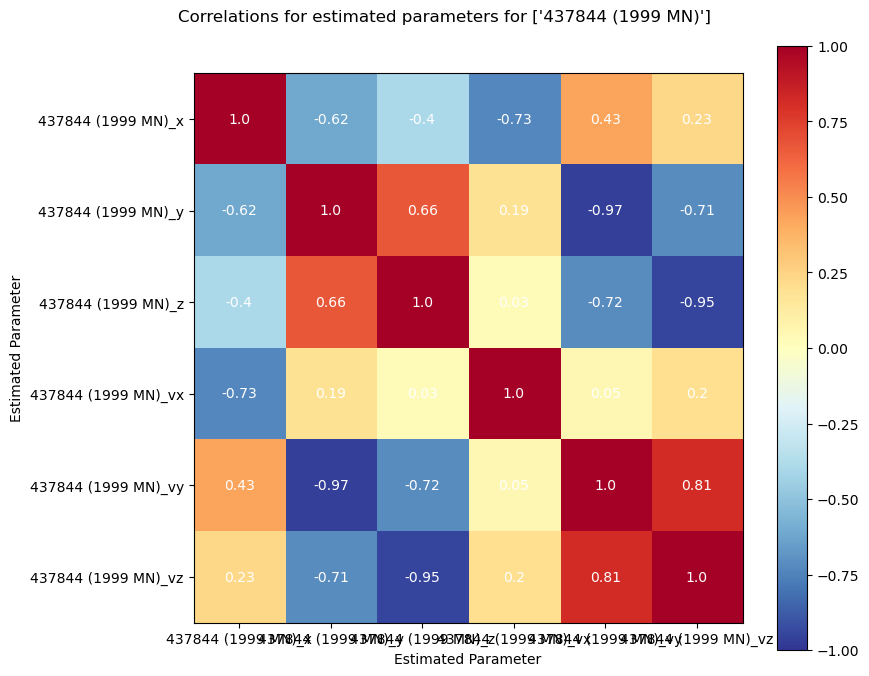

In [88]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

estimated_param_names = []

for i, obj in enumerate(asteroid_states):
    for name in ["x", "y", "z", "vx", "vy", "vz"]:
        estimated_param_names.append(f"{obj['name']}_{name}")


correlations = covariance_output.correlations
# estimated_param_names = ["x", "y", "z", "vx", "vy", "vz"]


fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

fig.suptitle(f"Correlations for estimated parameters for {target_name_list}")

fig.set_tight_layout(True)

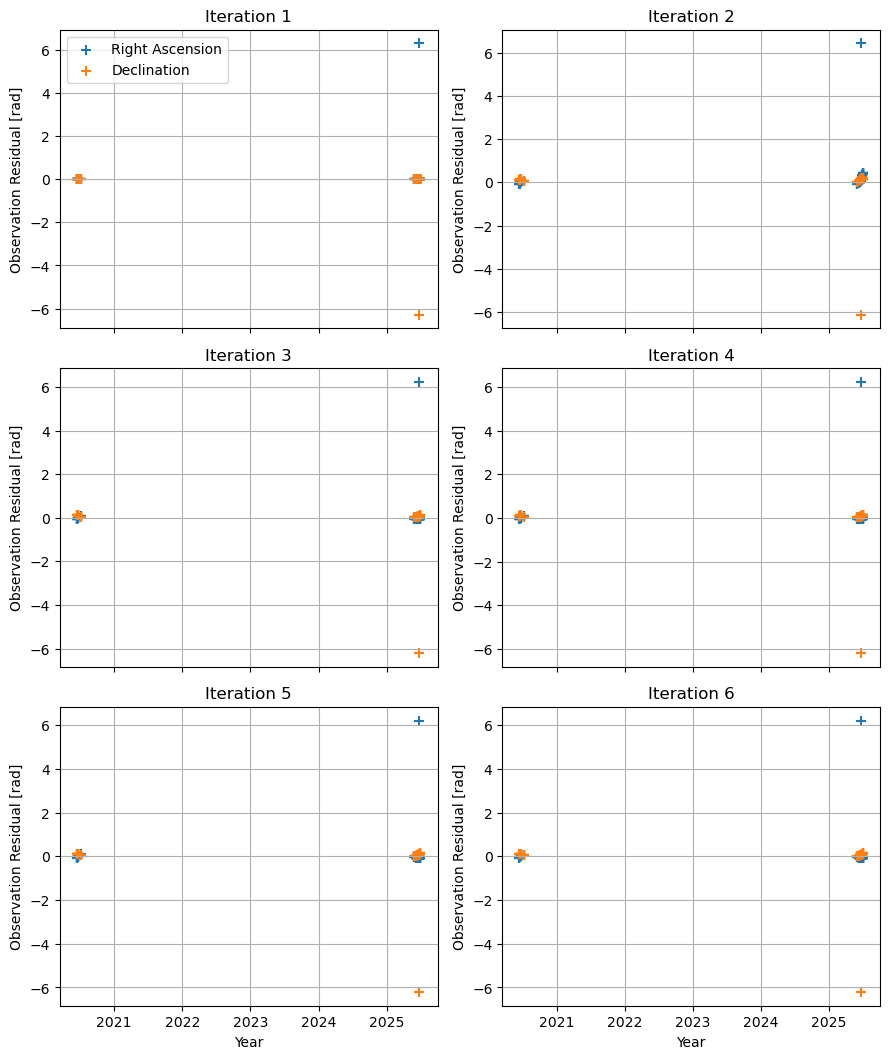

In [89]:
residual_history = pod_output.residual_history

# Number of columns and rows for our plot
number_of_columns = 2

number_of_rows = (
    int(number_of_pod_iterations / number_of_columns)
    if number_of_pod_iterations % number_of_columns == 0
    else int((number_of_pod_iterations + 1) / number_of_columns)
)

fig, axs = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(9, 3.5 * number_of_rows),
    sharex=True,
    sharey=False,
)

# We cheat a little to get an approximate year out of our times (which are in seconds since J2000)
residual_times = (
    np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000
)


# plot the residuals, split between RA and DEC types
for idx, ax in enumerate(fig.get_axes()):
    ax.grid()
    # we take every second
    ax.scatter(
        residual_times[::2],
        residual_history[
            ::2,
            idx,
        ],
        marker="+",
        s=60,
        label="Right Ascension",
    )
    ax.scatter(
        residual_times[1::2],
        residual_history[
            1::2,
            idx,
        ],
        marker="+",
        s=60,
        label="Declination",
    )
    ax.set_ylabel("Observation Residual [rad]")
    ax.set_title("Iteration " + str(idx + 1))

plt.tight_layout()

# add the year label for the x-axis
for col in range(number_of_columns):
    axs[int(number_of_rows - 1), col].set_xlabel("Year")

axs[0, 0].legend()

plt.show()

## Below this code is only for Icarus

In [ ]:
# retrieve the estimated initial state.
results_final = pod_output.parameter_history[:, -1]

vector_error_initial = (np.array(asteroid_states[0]["initial_guess"]) - asteroid_states[0]["true_state"])[0:3]
error_magnitude_initial = np.sqrt(np.square(vector_error_initial).sum()) / 1000

vector_error_final = (np.array(results_final) - asteroid_states[0]["true_state"])[0:3]
error_magnitude_final = np.sqrt(np.square(vector_error_final).sum()) / 1000

print(
    f"{target_name_list} initial guess radial error to spice: {round(error_magnitude_initial, 2)} km"
)
print(
    f"{target_name_list} final radial error to spice: {round(error_magnitude_final, 2)} km"
)

['1566 Icarus'] initial guess radial error to spice: 114.84 km
['1566 Icarus'] final radial error to spice: 6598142.06 km


In [ ]:
# n_states = 6 
# n_asteroids = len(asteroid_states)

# results_final = pod_output.parameter_history[:, -1]

# results_final = np.array(results_final)

# for i, obj in enumerate(asteroid_states):
#     start = i * n_states
#     end = (i + 1) * n_states

#     estimated = results_final[start:end]
#     truth = obj["true_state"]

#     error = estimated - truth

#     print(obj["name"])
#     print("Position error (km):", np.linalg.norm(error[:3]) / 1000)
#     print("Velocity error (km/s):", np.linalg.norm(error[3:]) / 1000)
#     print("-" * 40)

Calculating residuals and partials 456


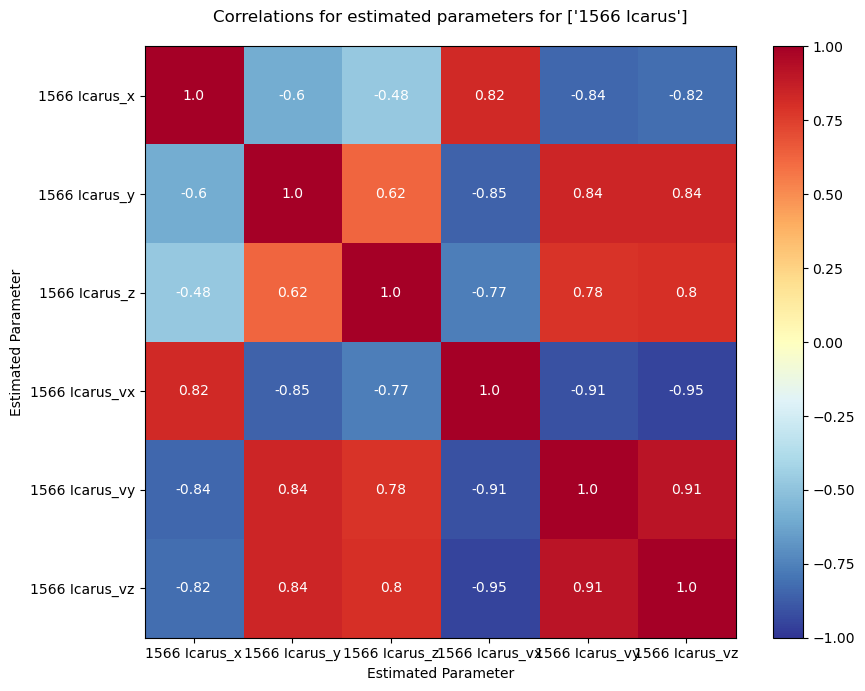

In [ ]:
# Correlation can be retrieved using the CovarianceAnalysisInput class:
covariance_input = estimation_analysis.CovarianceAnalysisInput(observation_collection)
covariance_output = estimator.compute_covariance(covariance_input)

estimated_param_names = []

for i, obj in enumerate(asteroid_states):
    for name in ["x", "y", "z", "vx", "vy", "vz"]:
        estimated_param_names.append(f"{obj['name']}_{name}")


correlations = covariance_output.correlations
# estimated_param_names = ["x", "y", "z", "vx", "vy", "vz"]


fig, ax = plt.subplots(1, 1, figsize=(9, 7))

im = ax.imshow(correlations, cmap=cm.RdYlBu_r, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)
ax.set_yticks(np.arange(len(estimated_param_names)), labels=estimated_param_names)

# add numbers to each of the boxes
for i in range(len(estimated_param_names)):
    for j in range(len(estimated_param_names)):
        text = ax.text(
            j, i, round(correlations[i, j], 2), ha="center", va="center", color="w"
        )

cb = plt.colorbar(im)

ax.set_xlabel("Estimated Parameter")
ax.set_ylabel("Estimated Parameter")

fig.suptitle(f"Correlations for estimated parameters for {target_name_list}")

fig.set_tight_layout(True)

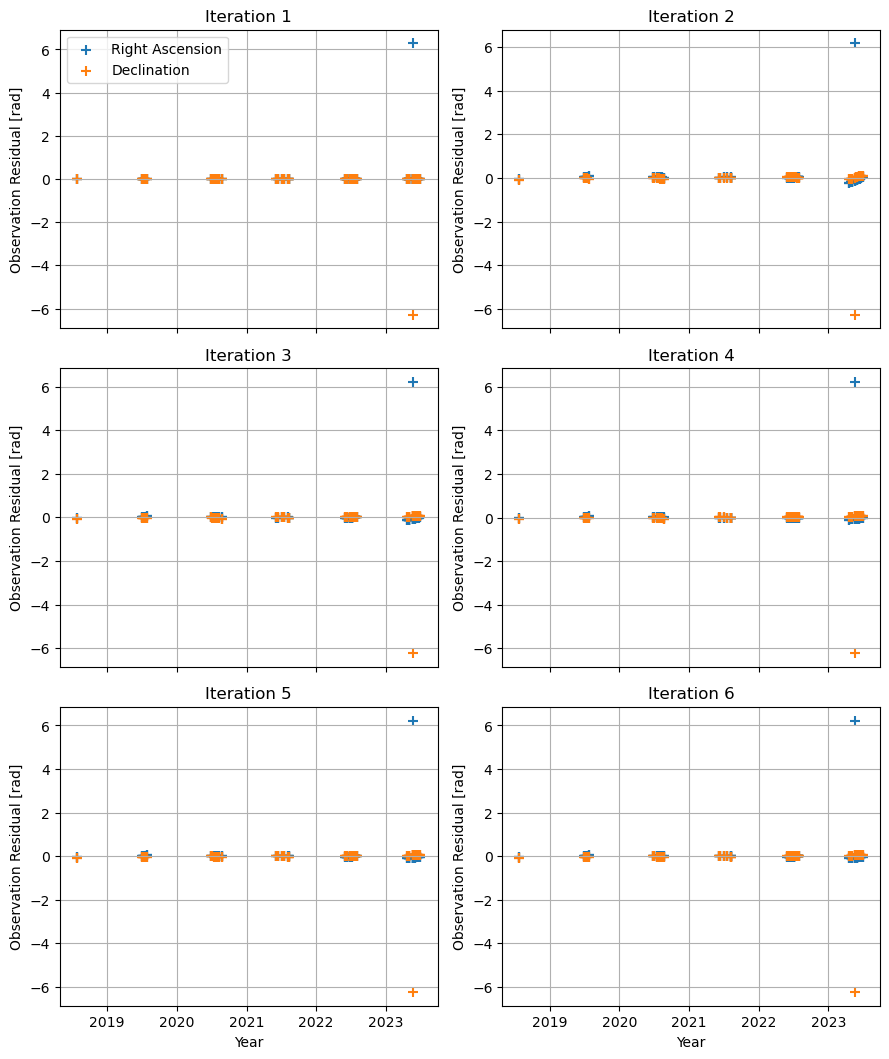

In [ ]:
residual_history = pod_output.residual_history

# Number of columns and rows for our plot
number_of_columns = 2

number_of_rows = (
    int(number_of_pod_iterations / number_of_columns)
    if number_of_pod_iterations % number_of_columns == 0
    else int((number_of_pod_iterations + 1) / number_of_columns)
)

fig, axs = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(9, 3.5 * number_of_rows),
    sharex=True,
    sharey=False,
)

# We cheat a little to get an approximate year out of our times (which are in seconds since J2000)
residual_times = (
    np.array(observation_collection.concatenated_times) / (86400 * 365.25) + 2000
)


# plot the residuals, split between RA and DEC types
for idx, ax in enumerate(fig.get_axes()):
    ax.grid()
    # we take every second
    ax.scatter(
        residual_times[::2],
        residual_history[
            ::2,
            idx,
        ],
        marker="+",
        s=60,
        label="Right Ascension",
    )
    ax.scatter(
        residual_times[1::2],
        residual_history[
            1::2,
            idx,
        ],
        marker="+",
        s=60,
        label="Declination",
    )
    ax.set_ylabel("Observation Residual [rad]")
    ax.set_title("Iteration " + str(idx + 1))

plt.tight_layout()

# add the year label for the x-axis
for col in range(number_of_columns):
    axs[int(number_of_rows - 1), col].set_xlabel("Year")

axs[0, 0].legend()

plt.show()

In [ ]:
# for spk_id, name in zip(target_spk_local_kernel, target_name_list):

#     try:
#         state = spice.get_body_cartesian_state_at_epoch(
#             spk_id,
#             global_frame_origin,
#             global_frame_orientation,
#             "NONE",
#             epoch_start_buffer
#         )
#         print(name, "OK")

#     except Exception as e:
#         print("FAILED:", name)
#         print(e)